# EDA — BDRs Brasil

Recorte del universo a las **BDRs brasileñas** (`dim_empresa.mercado = 'brasil'`, 14 tickers — se excluyen `NAT3D`/`VAL3D`, rotas en Yahoo: 404, sin precio ni métricas). No incluye las empresas brasileñas que cotizan como ADR directo en NYSE (VALE, PBR, NU, ABEV, etc.) — son la misma compañía que varias de estas BDRs vista por otro vehículo (ITUB↔ITUB3, SUZ↔SUZB3, TIMB↔TIMS3), mezclar los dos grupos duplicaría conceptualmente la misma empresa.

A diferencia del EDA general, acá el foco es la **exposición macro Brasil**: estas BDRs cotizan en B3 en reales (`fact_precios_daily` para `mercado='brasil'` está en BRL, no en USD — a diferencia de los tickers `usa_otros`), así que separamos cuánto del retorno es negocio real y cuánto es movimiento del tipo de cambio (`USDBRL`), y medimos la correlación de cada una contra el dólar y contra el índice local (`BOVESPA`) usando `fact_macro_daily`.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

con = duckdb.connect("../data/warehouse.duckdb", read_only=True)

dim_brasil = con.execute("""
    SELECT * FROM dim_empresa
    WHERE mercado = 'brasil' AND ticker_usd NOT IN ('NAT3D', 'VAL3D')
""").fetchdf()
BRASIL = dim_brasil["ticker_usd"].tolist()

metrics = con.execute("SELECT * FROM fact_metrics_daily WHERE ticker_usd = ANY(?)", [BRASIL]).fetchdf()
precios = con.execute(
    "SELECT * FROM fact_precios_daily WHERE ticker_usd = ANY(?) AND adj_close IS NOT NULL", [BRASIL]
).fetchdf()
macro_brasil = con.execute("SELECT * FROM fact_macro_daily WHERE serie IN ('USDBRL', 'BOVESPA')").fetchdf()

print(f"Universo: {len(BRASIL)} BDRs brasileñas")
print("dim_brasil:", dim_brasil.shape)
print("fact_metrics_daily:", metrics.shape)
print("fact_precios_daily:", precios.shape)
print("fact_macro_daily (USDBRL/BOVESPA):", macro_brasil.shape)

Universo: 12 BDRs brasileñas
dim_brasil: (12, 14)
fact_metrics_daily: (72, 29)
fact_precios_daily: (15384, 8)
fact_macro_daily (USDBRL/BOVESPA): (2556, 3)


## 1. Overview del subuniverso

Son pocas empresas (12 con datos completos), así que alcanza con mirarlas una por una en vez de agregarlas en gráficos de distribución como en el EDA general.

In [2]:
ultimo = metrics.sort_values("fecha").groupby("ticker_usd").last().reset_index()
overview = dim_brasil.merge(ultimo, on="ticker_usd")[
    ["ticker_usd", "nombre_empresa", "sector", "industria", "market_cap", "pe_trailing", "dividend_yield_pct"]
].sort_values("market_cap", ascending=False)
overview

,ticker_usd,nombre_empresa,sector,industria,market_cap,pe_trailing,dividend_yield_pct
2,ITUB3,Banco Itau Unibanco Sa,Financial Services,Banks - Regional,5.391900e+11,11.82,0.45
0,BPA11,Banco Btg Pactual S.A,Financial Services,Capital Markets,2.224583e+11,107.52,1.40
11,WEGE3,Weg S.A,Industrials,Electrical Equipment & Parts,2.158754e+11,34.53,3.01
1,BBAS3,Banco Do Brasil S.A,Financial Services,Banks - Regional,1.354145e+11,11.03,0.58
3,SBSP3,Cia De Saneamiento Basi,Utilities,Utilities - Regulated Water,9.927342e+10,12.01,2.46
9,SUZB3,Suzano S.A,Basic Materials,Paper & Paper Products,5.461971e+10,6.72,2.53
8,PRIO3,Petro Rio S.A,Energy,Oil & Gas E&P,5.024975e+10,13.21,0.00
5,RENT3,Localiza Rent A Car S.A,Industrials,Rental & Leasing Services,4.581942e+10,13.17,5.37
10,TIMS3,Tim S.A,Communication Services,Telecom Services,4.406117e+10,10.31,9.01
6,LREN3,Lojas Renner S.A,Consumer Cyclical,Department Stores,1.114682e+10,7.79,7.83


## 2. Valuación vs. sector (capa Gold)

`gold_comparables` ya compara cada empresa contra la mediana de su sector REAL (con `sector_corregido` aplicado donde Yahoo clasifica mal — ver `correcciones_sector.py`). Acá solo filtramos al subuniverso brasileño.

In [3]:
comparables_brasil = con.execute("SELECT * FROM gold_comparables WHERE ticker_usd = ANY(?)", [BRASIL]).fetchdf()

cols_comp = [
    "ticker_usd", "nombre_empresa", "sector", "pe_trailing", "comp_pe_mediana_sector", "comp_pe_vs_sector_pct",
    "margen_neto_pct", "comp_margen_vs_sector_pp", "crecimiento_ingresos_anual_pct", "comp_percentil_crecimiento_en_sector",
]
comparables_brasil[cols_comp].sort_values("comp_pe_vs_sector_pct")

,ticker_usd,nombre_empresa,sector,pe_trailing,comp_pe_mediana_sector,comp_pe_vs_sector_pct,margen_neto_pct,comp_margen_vs_sector_pp,crecimiento_ingresos_anual_pct,comp_percentil_crecimiento_en_sector
9,LREN3,Lojas Renner S.A,Consumer Cyclical,7.79,19.315,-59.7,9.4,3.8,9.6,65.0
1,SUZB3,Suzano S.A,Basic Materials,6.72,16.150,-58.4,17.1,9.1,5.7,45.0
7,RENT3,Localiza Rent A Car S.A,Industrials,13.17,22.820,-42.3,7.4,-0.9,12.1,76.0
2,TIMS3,Tim S.A,Communication Services,10.31,15.535,-33.6,15.8,6.4,4.6,31.0
0,BBAS3,Banco Do Brasil S.A,Financial Services,11.03,13.910,-20.7,21.8,-4.4,1.6,25.0
6,ITUB3,Banco Itau Unibanco Sa,Financial Services,11.82,13.910,-15.0,32.6,6.4,4.2,28.0
10,PRIO3,Petro Rio S.A,Energy,13.21,15.120,-12.6,18.1,8.1,8.5,76.0
4,SBSP3,Cia De Saneamiento Basi,Utilities,12.01,10.020,19.9,19.7,6.7,5.4,26.0
5,WEGE3,Weg S.A,Industrials,34.53,22.820,51.3,15.6,7.3,7.4,62.0
8,MGLU3,Magazine Luiza S.A,Consumer Cyclical,69.18,19.315,258.2,0.2,-5.4,1.7,29.0


## 3. Checklist Peter Lynch (capa Gold)

Mismo `gold_lynch` del EDA general, filtrado a este subuniverso.

In [4]:
lynch_brasil = con.execute("SELECT * FROM gold_lynch WHERE ticker_usd = ANY(?)", [BRASIL]).fetchdf()

cols_lynch = [
    "ticker_usd", "nombre_empresa", "lynch_categoria_auto", "lynch_checklist_score",
    "lynch_valuacion_peg", "crecimiento_ingresos_anual_pct", "deuda_patrimonio",
]
lynch_brasil[cols_lynch].sort_values("lynch_checklist_score", ascending=False)

,ticker_usd,nombre_empresa,lynch_categoria_auto,lynch_checklist_score,lynch_valuacion_peg,crecimiento_ingresos_anual_pct,deuda_patrimonio
7,MGLU3,Magazine Luiza S.A,Recuperable,3,Sin dato,1.7,76.23
4,HAPV3,Hapvida Participacoes I Investimentos Sa,Recuperable,3,Sin dato,9.2,32.98
1,BBAS3,Banco Do Brasil S.A,Recuperable,2,Sin dato,1.6,NaN
11,WEGE3,Weg S.A,Ciclica,2,Sin dato,7.4,28.90
10,TIMS3,Tim S.A,Bajo Crecimiento,1,Razonable,4.6,65.95
2,ITUB3,Banco Itau Unibanco Sa,Bajo Crecimiento,1,Razonable,4.2,NaN
0,BPA11,Banco Btg Pactual S.A,Alto Crecimiento,1,Sin dato,37.5,NaN
6,LREN3,Lojas Renner S.A,Estable,1,Sin dato,9.6,31.71
9,SUZB3,Suzano S.A,Ciclica,1,Sin dato,5.7,199.42
3,SBSP3,Cia De Saneamiento Basi,Estable,0,Sin dato,5.4,114.01


## 4. Retorno "limpio" vs. retorno cambiario

Estas BDRs cotizan en B3 en reales — `fact_precios_daily` las tiene en BRL, no en USD. El retorno nominal en reales (`retorno_brl_pct`) mezcla dos cosas: cómo le fue al negocio y cómo se movió el dólar contra el real en el medio. Dividimos el retorno del ticker por el retorno de `USDBRL` en la MISMA ventana para aislar el retorno "en dólares" (`retorno_usd_pct`) — lo que efectivamente ganó o perdió alguien que mide en USD, separado de la devaluación/apreciación del real.

La ventana usa la intersección de fechas entre el precio de cada ticker y la serie de `USDBRL` (que arranca más tarde que algunos precios, 2021-09-28 vs. 2021-08-16) — sin este ajuste el join da vacío.

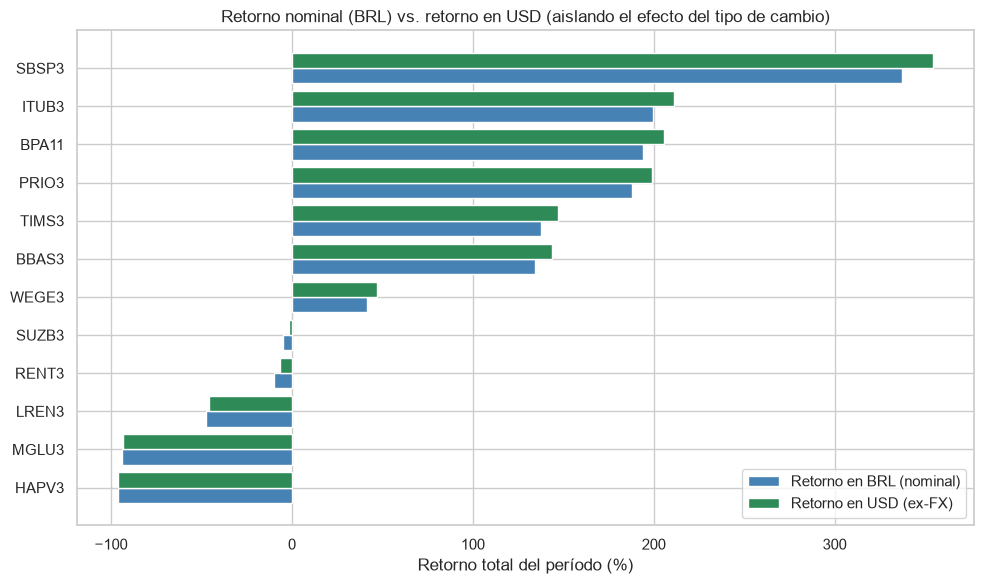

,ticker_usd,nombre_empresa,retorno_brl_pct,retorno_usdbrl_pct,retorno_usd_pct
8,SBSP3,Cia De Saneamiento Basi,337.3,-3.8,354.5
6,ITUB3,Banco Itau Unibanco Sa,199.4,-3.8,211.1
2,BPA11,Banco Btg Pactual S.A,194.3,-3.8,205.9
4,PRIO3,Petro Rio S.A,187.8,-3.8,199.1
1,TIMS3,Tim S.A,137.7,-3.8,147.1
3,BBAS3,Banco Do Brasil S.A,134.3,-3.8,143.5
11,WEGE3,Weg S.A,41.5,-3.8,47.1
0,SUZB3,Suzano S.A,-5.2,-3.8,-1.4
7,RENT3,Localiza Rent A Car S.A,-10.0,-3.8,-6.5
9,LREN3,Lojas Renner S.A,-47.8,-3.8,-45.7


In [5]:
q_fx = """
WITH rango AS (
    SELECT
        GREATEST((SELECT MIN(fecha) FROM fact_precios_daily WHERE ticker_usd = ANY(?) AND adj_close IS NOT NULL),
                 (SELECT MIN(fecha) FROM fact_macro_daily WHERE serie = 'USDBRL')) AS inicio,
        LEAST((SELECT MAX(fecha) FROM fact_precios_daily WHERE ticker_usd = ANY(?) AND adj_close IS NOT NULL),
              (SELECT MAX(fecha) FROM fact_macro_daily WHERE serie = 'USDBRL')) AS fin
),
precios_ticker AS (
    SELECT p.ticker_usd,
           FIRST(p.adj_close ORDER BY p.fecha) AS p_inicial,
           LAST(p.adj_close ORDER BY p.fecha) AS p_final
    FROM fact_precios_daily p, rango r
    WHERE p.ticker_usd = ANY(?) AND p.adj_close IS NOT NULL
      AND p.fecha BETWEEN r.inicio AND r.fin
    GROUP BY p.ticker_usd
),
usdbrl_rango AS (
    SELECT
        FIRST(m.valor ORDER BY m.fecha) AS u_inicial,
        LAST(m.valor ORDER BY m.fecha) AS u_final
    FROM fact_macro_daily m, rango r
    WHERE m.serie = 'USDBRL' AND m.fecha BETWEEN r.inicio AND r.fin
)
SELECT
    pt.ticker_usd,
    ROUND((pt.p_final / pt.p_inicial - 1) * 100, 1) AS retorno_brl_pct,
    ROUND((u.u_final / u.u_inicial - 1) * 100, 1) AS retorno_usdbrl_pct,
    ROUND(((pt.p_final / pt.p_inicial) / (u.u_final / u.u_inicial) - 1) * 100, 1) AS retorno_usd_pct
FROM precios_ticker pt, usdbrl_rango u
"""
retorno_fx = con.execute(q_fx, [BRASIL, BRASIL, BRASIL]).fetchdf().merge(
    dim_brasil[["ticker_usd", "nombre_empresa"]], on="ticker_usd"
)
retorno_fx = retorno_fx.sort_values("retorno_usd_pct", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(retorno_fx))
ax.barh([i + 0.2 for i in x], retorno_fx["retorno_brl_pct"], height=0.4, label="Retorno en BRL (nominal)", color="steelblue")
ax.barh([i - 0.2 for i in x], retorno_fx["retorno_usd_pct"], height=0.4, label="Retorno en USD (ex-FX)", color="seagreen")
ax.set_yticks(list(x))
ax.set_yticklabels(retorno_fx["ticker_usd"])
ax.invert_yaxis()
ax.set_xlabel("Retorno total del período (%)")
ax.set_title("Retorno nominal (BRL) vs. retorno en USD (aislando el efecto del tipo de cambio)")
ax.legend()
plt.tight_layout()
plt.show()

retorno_fx[["ticker_usd", "nombre_empresa", "retorno_brl_pct", "retorno_usdbrl_pct", "retorno_usd_pct"]]

## 5. Exposición macro: correlación vs. dólar y vs. Bovespa

Correlación del retorno DIARIO de cada BDR contra el cambio diario de `USDBRL` y contra el retorno diario de `BOVESPA` — mismo método que `gold/macro_sensitivity.py` (correlación de Pearson con `CORR()` de DuckDB), aplicado acá a las dos series relevantes para Brasil en vez de la tasa. Queda como query ad-hoc en la notebook, no como vista persistente — si en el futuro sirve para otro análisis, se promueve a `gold/`.

Lectura esperada: correlación alta y positiva contra Bovespa (son parte del índice, deberían moverse juntas) y correlación negativa contra USDBRL (cuando el dólar sube contra el real -suele ser salida de capitales/risk-off en emergentes- las acciones locales tienden a caer en reales).

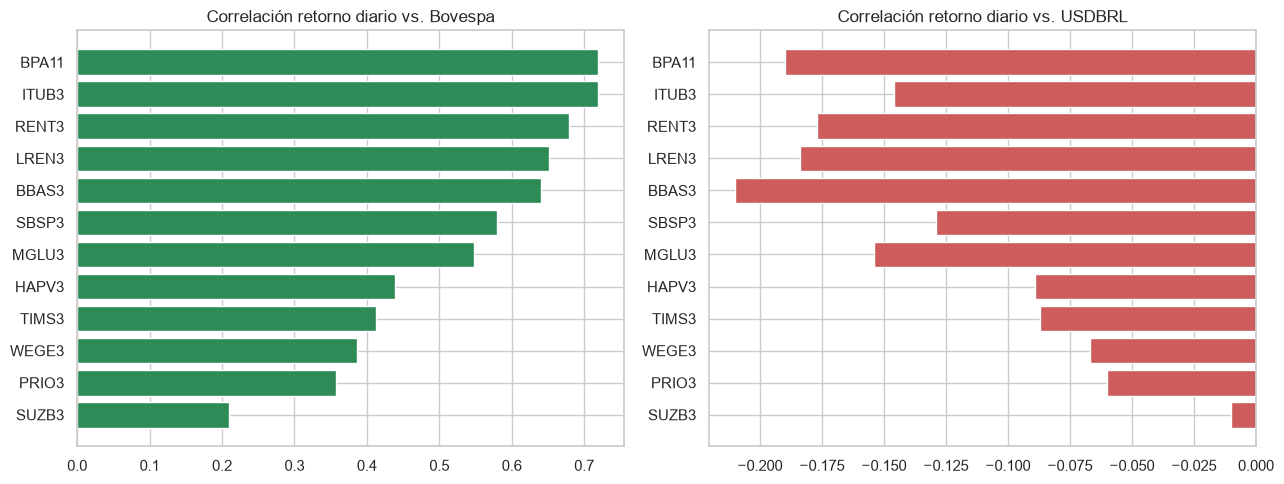

,ticker_usd,nombre_empresa,corr_vs_bovespa,corr_vs_usdbrl,dias_muestra
8,BPA11,Banco Btg Pactual S.A,0.719,-0.190,916
6,ITUB3,Banco Itau Unibanco Sa,0.719,-0.146,916
5,RENT3,Localiza Rent A Car S.A,0.679,-0.177,916
4,LREN3,Lojas Renner S.A,0.652,-0.184,916
9,BBAS3,Banco Do Brasil S.A,0.641,-0.210,916
0,SBSP3,Cia De Saneamiento Basi,0.580,-0.129,916
1,MGLU3,Magazine Luiza S.A,0.548,-0.154,916
11,HAPV3,Hapvida Participacoes I Investimentos Sa,0.439,-0.089,916
7,TIMS3,Tim S.A,0.413,-0.087,916
3,WEGE3,Weg S.A,0.387,-0.067,916


In [6]:
q_corr = """
WITH retornos_ticker AS (
    SELECT ticker_usd, fecha,
           adj_close / LAG(adj_close) OVER (PARTITION BY ticker_usd ORDER BY fecha) - 1 AS retorno
    FROM fact_precios_daily
    WHERE ticker_usd = ANY(?) AND adj_close IS NOT NULL
),
macro_wide AS (
    SELECT fecha,
           MAX(CASE WHEN serie = 'USDBRL' THEN valor END) AS usdbrl,
           MAX(CASE WHEN serie = 'BOVESPA' THEN valor END) AS bovespa
    FROM fact_macro_daily WHERE serie IN ('USDBRL', 'BOVESPA')
    GROUP BY fecha
),
macro_retornos AS (
    SELECT fecha,
           usdbrl / LAG(usdbrl) OVER (ORDER BY fecha) - 1 AS ret_usdbrl,
           bovespa / LAG(bovespa) OVER (ORDER BY fecha) - 1 AS ret_bovespa
    FROM macro_wide
)
SELECT
    r.ticker_usd,
    COUNT(*) AS dias_muestra,
    ROUND(CORR(r.retorno, m.ret_usdbrl), 3) AS corr_vs_usdbrl,
    ROUND(CORR(r.retorno, m.ret_bovespa), 3) AS corr_vs_bovespa
FROM retornos_ticker r
JOIN macro_retornos m USING (fecha)
WHERE r.retorno IS NOT NULL AND m.ret_usdbrl IS NOT NULL AND m.ret_bovespa IS NOT NULL
GROUP BY r.ticker_usd
"""
exposicion = con.execute(q_corr, [BRASIL]).fetchdf().merge(dim_brasil[["ticker_usd", "nombre_empresa"]], on="ticker_usd")
exposicion = exposicion.sort_values("corr_vs_bovespa", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(exposicion["ticker_usd"], exposicion["corr_vs_bovespa"], color="seagreen")
axes[0].set_title("Correlación retorno diario vs. Bovespa")
axes[0].invert_yaxis()
axes[1].barh(exposicion["ticker_usd"], exposicion["corr_vs_usdbrl"], color="indianred")
axes[1].set_title("Correlación retorno diario vs. USDBRL")
axes[1].axvline(0, color="grey", linewidth=0.8)
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

exposicion[["ticker_usd", "nombre_empresa", "corr_vs_bovespa", "corr_vs_usdbrl", "dias_muestra"]]

## 6. Ranking final

Cruza todo lo de arriba: checklist de Lynch, cuán barata está vs. su sector real, y cuánto le pegó/ayudó el tipo de cambio en el período.

In [7]:
ranking = (
    lynch_brasil[["ticker_usd", "nombre_empresa", "lynch_categoria_auto", "lynch_checklist_score", "lynch_valuacion_peg"]]
    .merge(comparables_brasil[["ticker_usd", "comp_pe_vs_sector_pct", "comp_percentil_crecimiento_en_sector"]], on="ticker_usd")
    .merge(retorno_fx[["ticker_usd", "retorno_usd_pct"]], on="ticker_usd")
    .merge(exposicion[["ticker_usd", "corr_vs_bovespa", "corr_vs_usdbrl"]], on="ticker_usd")
    .sort_values(["lynch_checklist_score", "comp_pe_vs_sector_pct"], ascending=[False, True])
)
ranking

,ticker_usd,nombre_empresa,lynch_categoria_auto,lynch_checklist_score,lynch_valuacion_peg,comp_pe_vs_sector_pct,comp_percentil_crecimiento_en_sector,retorno_usd_pct,corr_vs_bovespa,corr_vs_usdbrl
7,MGLU3,Magazine Luiza S.A,Recuperable,3,Sin dato,258.2,29.0,-93.5,0.548,-0.154
4,HAPV3,Hapvida Participacoes I Investimentos Sa,Recuperable,3,Sin dato,NaN,57.0,-96.0,0.439,-0.089
1,BBAS3,Banco Do Brasil S.A,Recuperable,2,Sin dato,-20.7,25.0,143.5,0.641,-0.210
11,WEGE3,Weg S.A,Ciclica,2,Sin dato,51.3,62.0,47.1,0.387,-0.067
6,LREN3,Lojas Renner S.A,Estable,1,Sin dato,-59.7,65.0,-45.7,0.652,-0.184
9,SUZB3,Suzano S.A,Ciclica,1,Sin dato,-58.4,45.0,-1.4,0.209,-0.010
10,TIMS3,Tim S.A,Bajo Crecimiento,1,Razonable,-33.6,31.0,147.1,0.413,-0.087
2,ITUB3,Banco Itau Unibanco Sa,Bajo Crecimiento,1,Razonable,-15.0,28.0,211.1,0.719,-0.146
0,BPA11,Banco Btg Pactual S.A,Alto Crecimiento,1,Sin dato,673.0,87.0,205.9,0.719,-0.190
5,RENT3,Localiza Rent A Car S.A,Ciclica,0,Sin dato,-42.3,76.0,-6.5,0.679,-0.177
